In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Exercise 4.1

In [3]:
data = pd.read_csv('population_us.csv')
data

,year,age,sex,people
0,1850,0,1,1483789
1,1850,0,2,1450376
2,1850,5,1,1411067
3,1850,5,2,1359668
4,1850,10,1,1260099
...,...,...,...,...
565,2000,80,2,3221898
566,2000,85,1,970357
567,2000,85,2,1981156
568,2000,90,1,336303


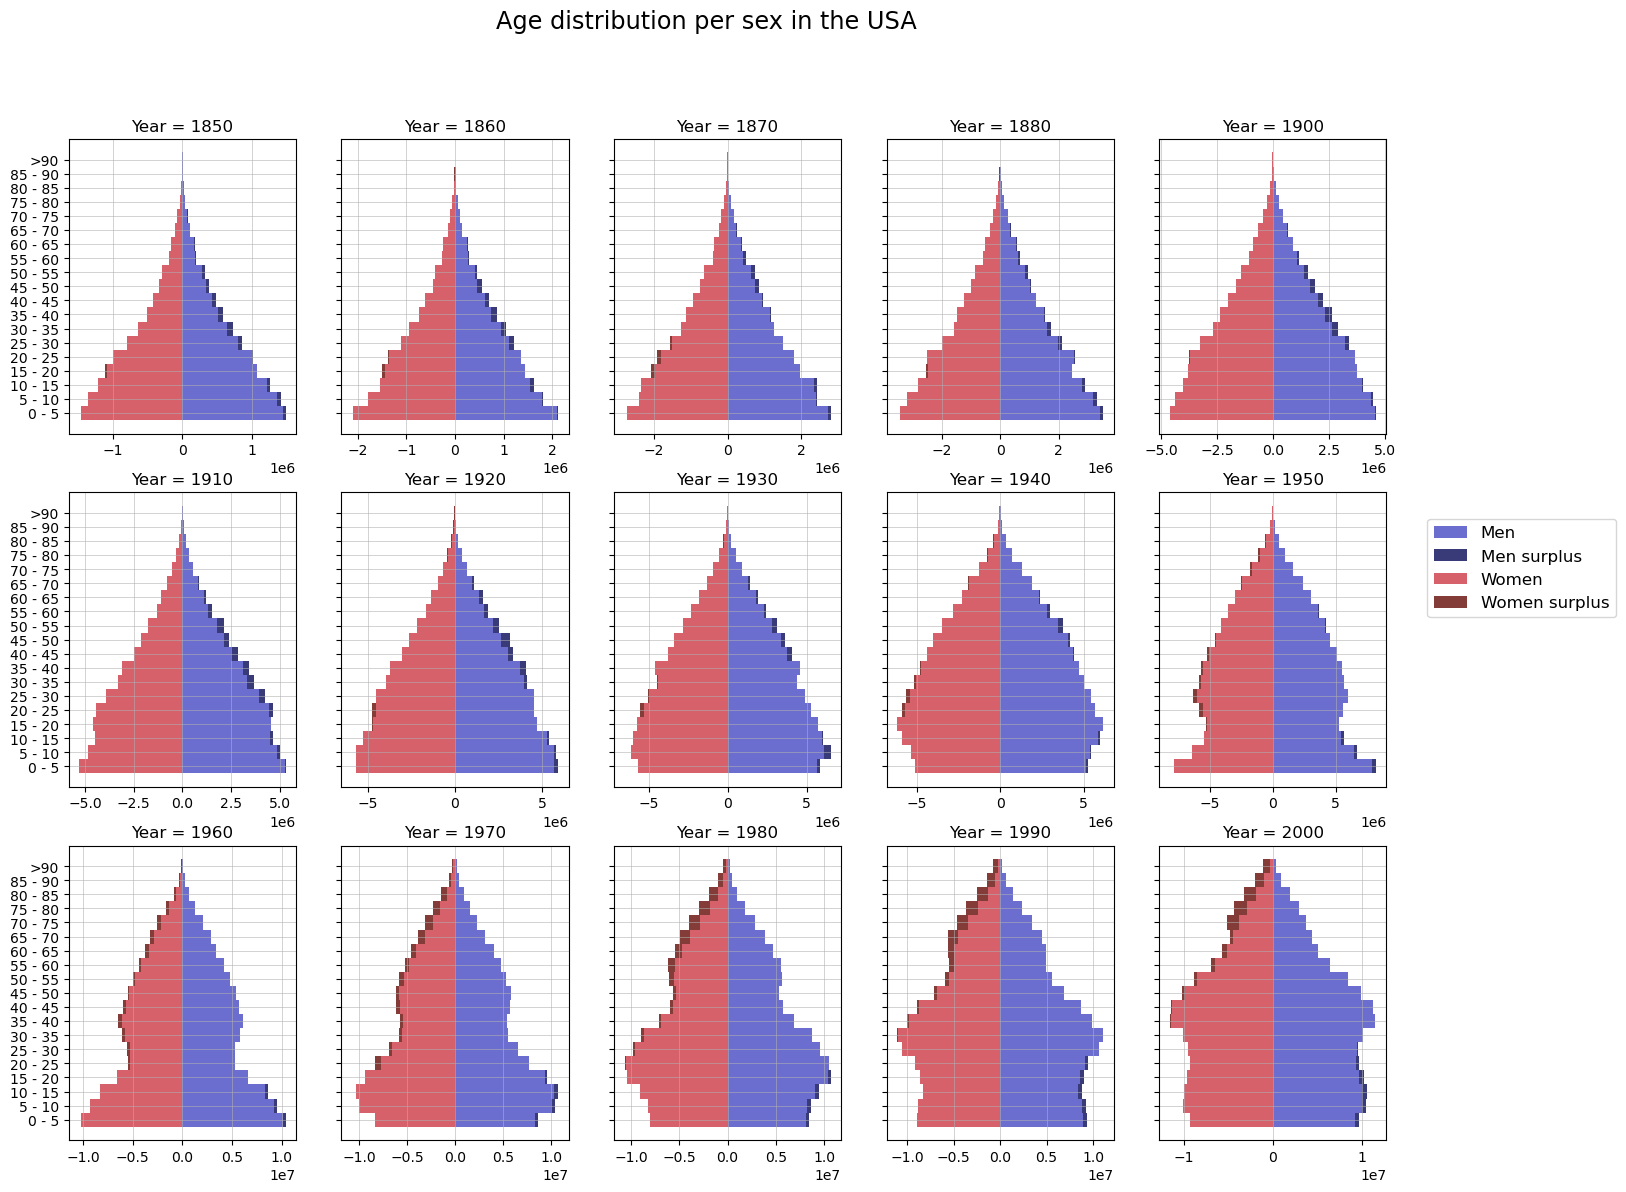

In [4]:
# Horizontal bar plot with surpluses:

# Clear plot for comparison of the whole population distribution over time.
# Male / female ratio can be clearly seen in here as well.
# Downside: Creating the plot is rather hard.

age_range = [f"{i} - {i+5}" if i < 90 else ">90" for i in range(0, 91, 5)]
fig, axs = plt.subplots(3, 5, figsize = (17,13))
for i, year in enumerate(data['year'].unique()):
    df_temp = data[data["year"] == year]
    men_num = df_temp[df_temp["sex"] == 1]["people"].to_numpy()
    women_num = df_temp[df_temp["sex"] == 2]["people"].to_numpy()
    min_num = np.minimum(men_num, women_num)
    ax = axs[int(i/5), i % 5]
    ax.barh(age_range, min_num, height = 1, color=plt.cm.tab20b(2), label="Men") # light blue
    ax.barh(age_range, men_num-min_num, height = 1, left = min_num,
    color=plt.cm.tab20b(0), label="Men surplus") # dark blue
    ax.barh(age_range, -min_num, height = 1, color=plt.cm.tab20b(14), label="Women") # light red (symmetric with light blue)
    ax.barh(age_range, min_num-women_num, height = 1, left = -min_num,
    color=plt.cm.tab20b(12), label="Women surplus") # dark red
    ax.set_title(f"Year = {year}")
    if i % 5 != 0:
        ax.set_yticklabels([])
    ax.grid(linewidth=0.4)
    ax.set_xlim(-df_temp["people"].max() * 1.1, df_temp["people"].max() * 1.1)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", fontsize = "large",bbox_to_anchor = (1.04, 0.55))
fig.suptitle("Age distribution per sex in the USA", fontsize = "xx-large")
plt.show()

In [5]:
# Violin plot:

# The standard Seaborn violin plot function takes in unweighted datapoints. 
# On the dataset "data" above, it would only see 
# "there is exactly one datapoint for the year x, age y, sex z for any given x, y, z"
# and would plot a uniformly thick violin plot for each year.
# It can not tell that the value "people" indicates a weight.
#
# To trick it, we create a dataset containing many entries for any given year, age and sex, 
# proportionally to the number of people in that sex and age group in the given year.

violin_data = []
for name, values in data.groupby(['year', 'age', 'sex']):
    violin_data.extend([name] * int(values['people'].values[0] * 1e-5))
violin_data = pd.DataFrame(violin_data, columns=['year', 'age', 'sex']).replace({1: 'male', 2: 'female'})
violin_data

,year,age,sex
0,1850,0,male
1,1850,0,male
2,1850,0,male
3,1850,0,male
4,1850,0,male
...,...,...,...
19256,2000,90,female
19257,2000,90,female
19258,2000,90,female
19259,2000,90,female


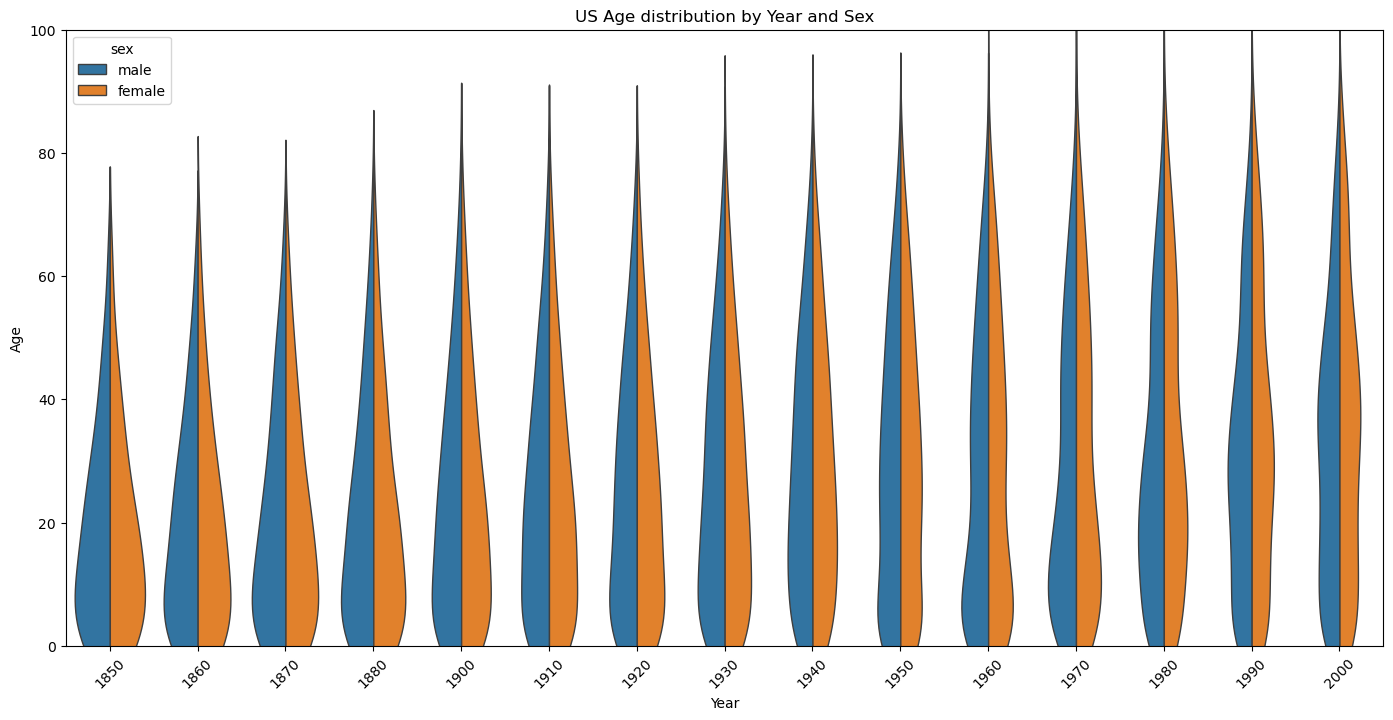

In [6]:
plt.figure(figsize=(17, 8))
sns.violinplot(x='year', y='age', hue='sex', data=violin_data, split=True, inner=None, linewidth=1)#, density_norm="count")

plt.ylim((0,100))
plt.title('US Age distribution by Year and Sex')
plt.xlabel('Year')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()

# By using density_norm = "count" in the sns.violinplot, one can make the area of the violin proportional to the overall population in the given year.
# As the population before 1900 was so much smaller than today, the violins for the early years become almost unreadable though.

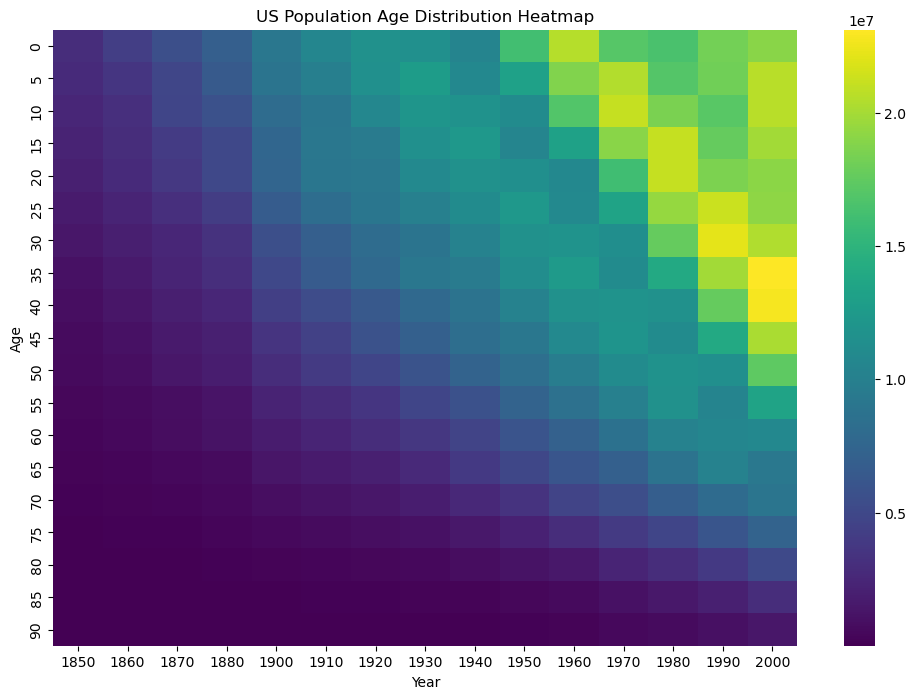

In [7]:
# A heatmap with year and age axes makes it easy to track cohorts through time (following diagonal stripes in the plot.
# For instance, one can quite clearly see the "baby boomers" born in the 50s and 60s

# pivot table for the heatmap
age_heatmap = data.pivot_table(index='age', columns='year', values='people', aggfunc='sum')

# heatmap to visualize age distribution over time
plt.figure(figsize=(12, 8))
sns.heatmap(age_heatmap, cmap='viridis', annot=False, cbar=True)
plt.title('US Population Age Distribution Heatmap')
plt.xlabel('Year')
plt.ylabel('Age')
plt.show()

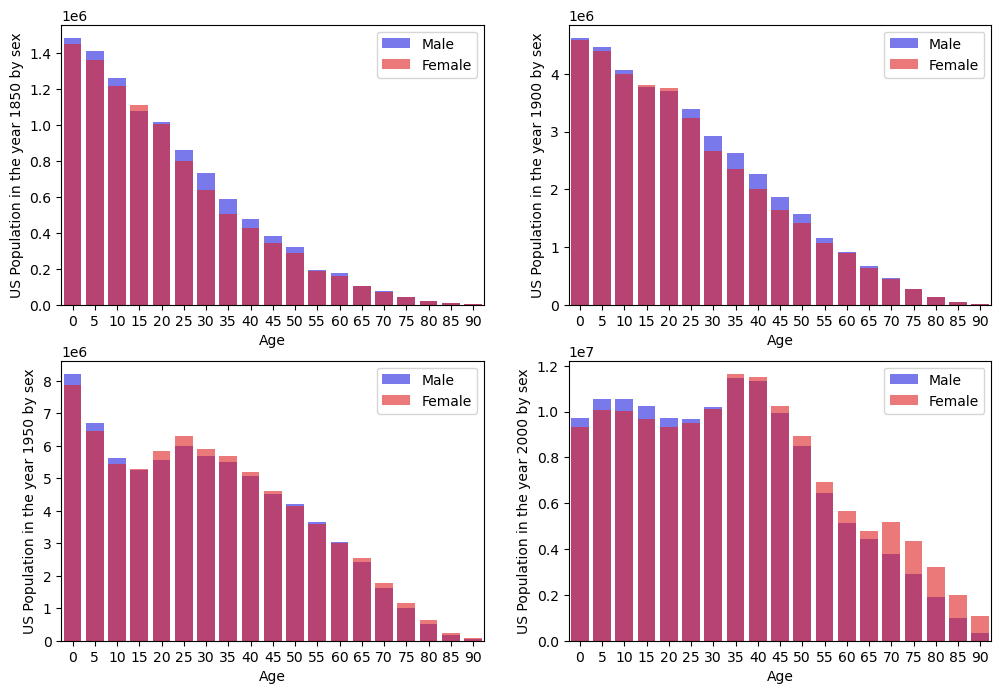

In [8]:
# This barplot is a simple way to plot the population distribution in age and sex. 
# The use of the alpha channel creates the effect of a stacked bar chart through overlapping of colors.
# Small caution note: 
# The colors don't match with the ones from the first figure in the sample solutions above, and the overlap is not explained in the legend.

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

plot_years = [1850,1900,1950,2000]

for ax, year in zip(axs.flatten(),plot_years):
    # Filtered data for males and females
    males = data[(data['sex'] == 1) & (data['year'] == year)]
    females = data[(data['sex'] == 2) & (data['year'] == year)]
    
    # side-by-side bar plot to compare male and female distributions
    sns.barplot(data=males, x='age', y='people', label='Male', color='b', alpha=0.6, ax=ax)
    sns.barplot(data=females, x='age', y='people', label='Female', color='r', alpha=0.6, ax=ax)
    ax.legend()
    ax.set_xlabel('Age')
    ax.set_ylabel('US Population in the year '+str(year)+' by sex')

## Exercise 4.2

In [9]:
# generate M samples of X_N
def generate_samples(M, N):
    x_i_samples = np.random.choice([-1, 1], size = (M, N))
    X_N_samples = x_i_samples.sum(axis = 1) / np.sqrt(N)
    return X_N_samples

N_samples =  [1, 3, 10, 30, 100]
M = 10000

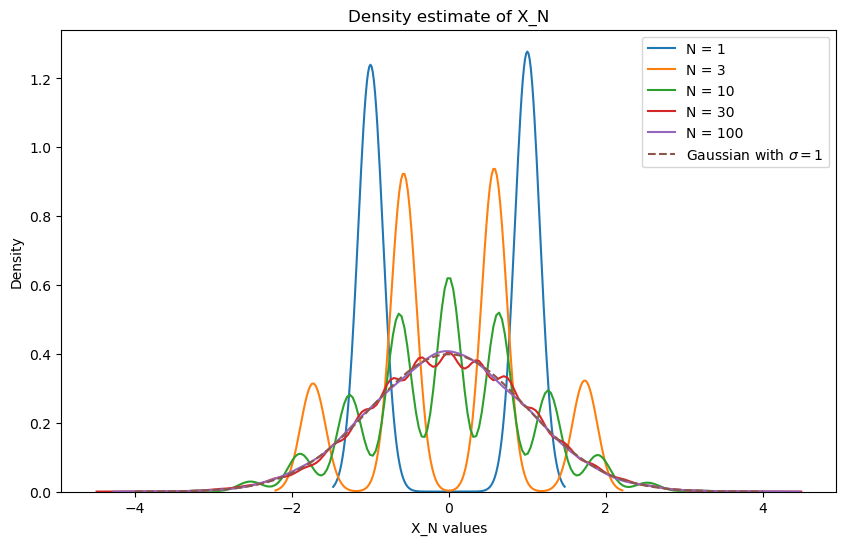

In [10]:
# kernel density estimate (like a histogram but smooth)
plt.figure(figsize=(10,6))
for N in N_samples:
    X_N_samples = generate_samples(M, N)
    sns.kdeplot(X_N_samples, label = f'N = {N}')

def gaussian(x, sigma):
    return 1./(np.sqrt(2.*np.pi)*sigma) * np.exp(-((x)/sigma)**2/2)

xrange = np.linspace(-4,4,100)
plt.plot(xrange,gaussian(xrange,1),linestyle='--',label=r"Gaussian with $\sigma=1$")


plt.title('Density estimate of X_N')
plt.xlabel('X_N values')
plt.ylabel('Density')
plt.legend()
plt.show()